<a href="https://colab.research.google.com/github/Abhi01shinde/Python-project/blob/main/Iot_Predictive_Maintenance_Engine_Project_week1_%26_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title: IoT Predictive Maintenance Engine.
Product Brand Name: "FactoryGuard AI"

Week **1**

In [ ]:
import pandas as pd

df = pd.read_csv('ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


1. LOADING AND EXPLORING THE DATA

     Imports the data (ai4i2020.csv) using pandas.read_csv.
     
     Checks the size, columns, data types, and any missing values.

** WEEK-1 :DATA EXPLORATION
           
           The Process of examining a dataset to understand its main characterstics, structure, and contents.


*   df.shape: It returns thedimensions of dataset as a tuple.This helps in understanding the size of data.
*   df.coloums: List of all coloums name in the Dataframe.
*   df.info(): Displays a concise summary of the DataFrame'
*   df.isnull().sum(): Calculates the total number of missing (null) values per column.







DATASET OVERVIEW
**  The dataset comprises machine sensor readings, including air temperature, process temperature, rotational speed, torque, and tool wear, which are used to monitor machine operation.

In [ ]:
# Rename columns for clarity
df = df.rename(columns={
    'Air temperature [K]': 'air_temp_k',
    'Process temperature [K]': 'process_temp_k',
    'Rotational speed [rpm]': 'rotational_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure'
})

# Convert temperatures from Kelvin to Celsius
df['air_temp_c'] = df['air_temp_k'] - 273.15
df['process_temp_c'] = df['process_temp_k'] - 273.15

# Drop original Kelvin columns
df.drop(['air_temp_k', 'process_temp_k'], axis=1, inplace=True)

# Show the structure and a sample of the data
print("Data types and info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

# Optional: Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UDI               10000 non-null  int64  
 1   Product ID        10000 non-null  object 
 2   Type              10000 non-null  object 
 3   rotational_speed  10000 non-null  int64  
 4   torque            10000 non-null  float64
 5   tool_wear         10000 non-null  int64  
 6   machine_failure   10000 non-null  int64  
 7   TWF               10000 non-null  int64  
 8   HDF               10000 non-null  int64  
 9   PWF               10000 non-null  int64  
 10  OSF               10000 non-null  int64  
 11  RNF               10000 non-null  int64  
 12  air_temp_c        10000 non-null  float64
 13  process_temp_c    10000 non-null  float64
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB
None

First few rows:
   UDI Product ID Type  rotational_

DATA CLEANING

**  During the data cleaning phase, column names were simplified for clarity, and temperature measurements were converted from Kelvin to Celsius, enhancing interpretability. With these adjustments, the dataset is prepared for feature analysis.

                       UDI  rotational_speed    torque  tool_wear  \
UDI               1.000000         -0.006615  0.003207  -0.010702   
rotational_speed -0.006615          1.000000 -0.875027   0.000223   
torque            0.003207         -0.875027  1.000000  -0.003093   
tool_wear        -0.010702          0.000223 -0.003093   1.000000   
machine_failure  -0.022892         -0.044188  0.191321   0.105448   
TWF               0.009154          0.010389 -0.014662   0.115792   
HDF              -0.022215         -0.121241  0.142610  -0.001287   
PWF              -0.023557          0.123018  0.083781  -0.009334   
OSF              -0.000990         -0.104575  0.183465   0.155894   
RNF              -0.005954         -0.013088  0.016136   0.011326   
air_temp_c        0.117428          0.022670 -0.013778   0.013853   
process_temp_c    0.324428          0.019277 -0.014061   0.013488   

                  machine_failure       TWF       HDF       PWF       OSF  \
UDI                     -

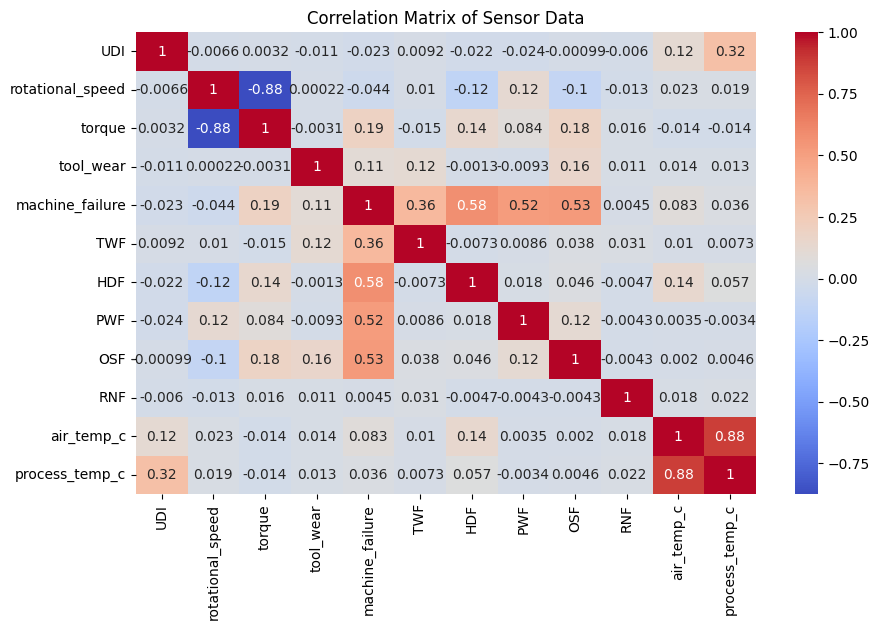

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Display the correlation matrix
print(corr_matrix)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Sensor Data')
plt.show()

Correlation Analysis
**  I was generated to analyze the relationships between sensor variables and machine failure.
The heatmap visualization helps identify which features are positively or negatively correlated with failure.


In [ ]:
# ----- FEATURE ENGINEERING (Lag + Rolling) -----

sensor_cols = [
    'rotational_speed',
    'torque',
    'tool_wear',
    'air_temp_c',
    'process_temp_c'
]

# Create lag features (t-1, t-2)
for col in sensor_cols:
    df[f'{col}_t-1'] = df[col].shift(1)
    df[f'{col}_t-2'] = df[col].shift(2)

# Create rolling statistics (window = 3)
for col in sensor_cols:
    df[f'{col}_roll_mean_3'] = df[col].rolling(window=3).mean()
    df[f'{col}_roll_std_3'] = df[col].rolling(window=3).std()

# Drop rows with NaN values created due to lag/rolling
df.dropna(inplace=True)

print("Feature engineering completed successfully")
print(df.head())


Feature engineering completed successfully
   UDI Product ID Type  rotational_speed  torque  tool_wear  machine_failure  \
2    3     L47182    L              1498    49.4          5                0   
3    4     L47183    L              1433    39.5          7                0   
4    5     L47184    L              1408    40.0          9                0   
5    6     M14865    M              1425    41.9         11                0   
6    7     L47186    L              1558    42.4         14                0   

   TWF  HDF  PWF  ...  rotational_speed_roll_mean_3  \
2    0    0    0  ...                   1485.666667   
3    0    0    0  ...                   1446.333333   
4    0    0    0  ...                   1446.333333   
5    0    0    0  ...                   1422.000000   
6    0    0    0  ...                   1463.666667   

   rotational_speed_roll_std_3  torque_roll_mean_3  torque_roll_std_3  \
2                    72.293384           46.166667           3.302020   

FEATURE EXTRACTION
** Lag and rolling window features are engineered to capture temporal dependencies and recent trends in the sensor data. Lag features reflect past sensor values, while rolling features summarize recent sensor behavior, both of which can help machine learning models detect patterns leading up to machine failure.

In [ ]:
# Split the data in order of time to avoid data leakage
X = df.drop('machine_failure', axis=1)
y = df['machine_failure']

# Find the index to split at 80%
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 7998, Test size: 2000


TRAIN - TEST SPLIT DATASET

**  It is the process of dividing your dataset into two parts: one for training your machine learning model (train), and another for evaluating its performance on unseen data (test).

In [ ]:
# Drop non-numeric / identifier columns
columns_to_drop = ['Product ID', 'Type']

X_train_model = X_train.drop(columns=columns_to_drop)
X_test_model  = X_test.drop(columns=columns_to_drop)


DATA LEAKAGING

** It occurs when the training data includes information that would not be available at prediction time, such as data from the future or from the target variable.

Week 2

MODELLING

** The process of creating a machine learning model that can learn from data and make predictions or classifications.

HYPERPARAMETER TUNING

** The process of finding the best set of parameters that control how your machine learning model learns(such as the number of trees in a forest, learning rate, or tree depth).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score

# Identify non-numeric columns that need to be dropped from X_train and X_test
columns_to_drop_from_X = ['Product ID', 'Type']

# Drop these columns from X_train and X_test before training
X_train_processed = X_train.drop(columns=columns_to_drop_from_X)
X_test_processed = X_test.drop(columns=columns_to_drop_from_X)

# Train a baseline Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, digits=4))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("Recall:  ", recall_score(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995      1961
           1     1.0000    0.9487    0.9737        39

    accuracy                         0.9990      2000
   macro avg     0.9995    0.9744    0.9866      2000
weighted avg     0.9990    0.9990    0.9990      2000

F1-score: 0.9736842105263158
Recall:   0.9487179487179487


RANDOM FOREST

** It is an ensemble learning method that builds multiple decision trees during training and merges their predictions to get a more accurate and stable prediction.

CLASSIFICATION REPORT

** It includes precision, recall, F1-score, and support for each class, providing a quick overview of how well the model performed on different categories.


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'gamma': [0, 0.1, 0.3, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

columns_to_drop = ['Product ID', 'Type']

X_train_model = X_train.drop(columns=columns_to_drop)
X_test_model  = X_test.drop(columns=columns_to_drop)

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    n_jobs=-1,
    cv=3,
    verbose=2,
    random_state=42
)

# ✅ CORRECT FIT
search.fit(X_train_model, y_train)

print("Best hyperparameters:", search.best_params_)

# ✅ CORRECT PREDICTION
y_pred_xgb = search.predict(X_test_model)

print("XGBoost Results (Optimized):")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("Recall:  ", recall_score(y_test, y_pred_xgb))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best hyperparameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}
XGBoost Results (Optimized):
              precision    recall  f1-score   support

           0     0.9985    1.0000    0.9992      1961
           1     1.0000    0.9231    0.9600        39

    accuracy                         0.9985      2000
   macro avg     0.9992    0.9615    0.9796      2000
weighted avg     0.9985    0.9985    0.9985      2000

F1-score: 0.96
Recall:   0.9230769230769231


XGBoost Model with RandomizedSearchCV

** RandomizedSearchCV tunes the XGBoost hyperparameters for best F1-score (you can adjust for 'recall' scoring as needed).

** Evaluation focuses not just on accuracy, but on F1-score and recall—especially important for minimizing false negatives (catching machine failures).

** Compare the F1 and Recall of both models. Your goal is to beat the baseline Random Forest with the optimized XGBoost.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, recall_score
from sklearn.linear_model import LogisticRegression



In [ ]:
# Logistic Regression baseline pipeline
log_reg_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # Important for failure imbalance
        random_state=42
    ))
])


In [ ]:
# use numeric-only features
log_reg_pipeline.fit(X_train_model, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test_model)


In [ ]:
print("Logistic Regression Baseline Results:")
print(classification_report(y_test, y_pred_lr, digits=4))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("Recall:  ", recall_score(y_test, y_pred_lr))


Logistic Regression Baseline Results:
              precision    recall  f1-score   support

           0     0.9990    0.9995    0.9992      1961
           1     0.9737    0.9487    0.9610        39

    accuracy                         0.9985      2000
   macro avg     0.9863    0.9741    0.9801      2000
weighted avg     0.9985    0.9985    0.9985      2000

F1-score: 0.961038961038961
Recall:   0.9487179487179487


WEEK 3


In [ ]:
search.fit(X_train_model, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:04:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
best_model = search.best_estimator_


In [ ]:
!pip install shap


In [ ]:
import shap


In [ ]:
explainer = shap.Explainer(best_model, X_train_model)


In [ ]:
shap_values = explainer(X_test_model)


 97%|=================== | 1945/2000 [00:22<00:00]       

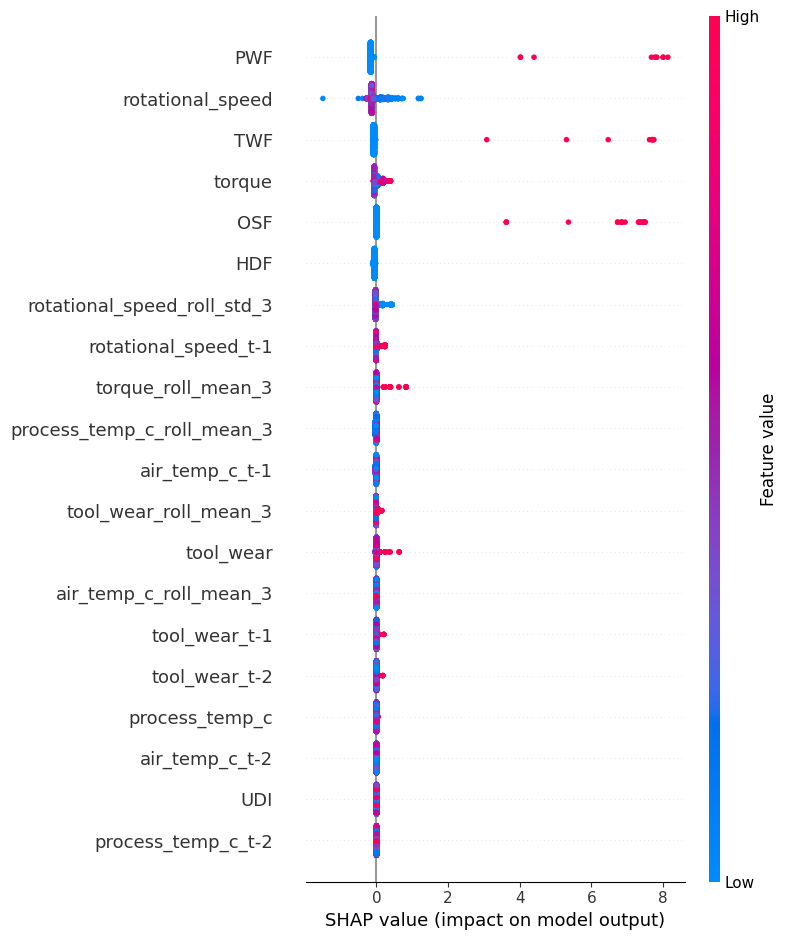

In [ ]:
shap.summary_plot(shap_values, X_test_model)



In [ ]:
shap.initjs()


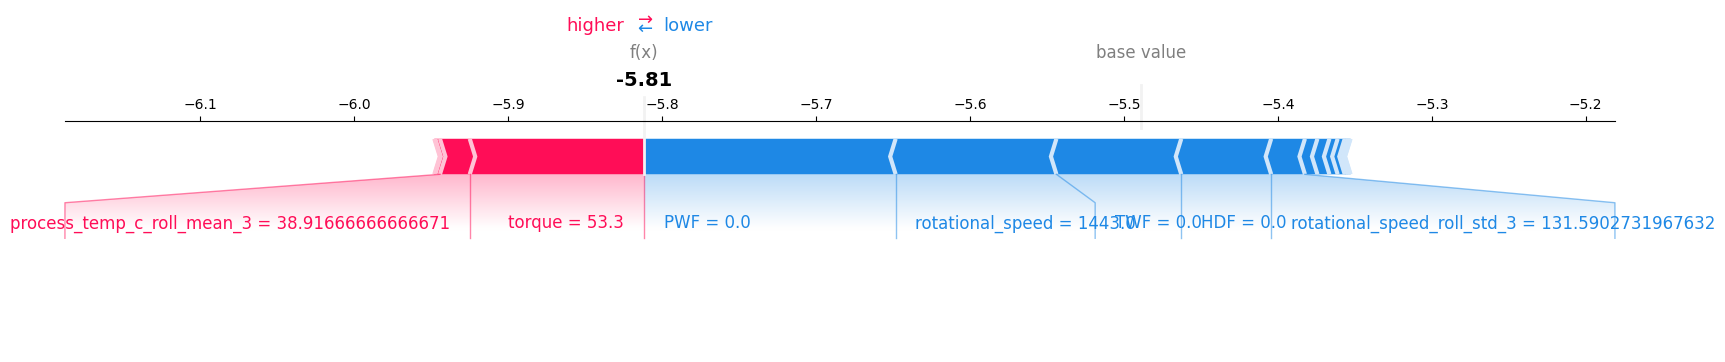

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test_model.iloc[0],
    matplotlib=True
)


## Local Explanation using SHAP Force Plot

The SHAP force plot explains the contribution of individual features for a single prediction.
Features shown in red increase the likelihood of machine failure, while blue features decrease it.
This provides instance-level interpretability of the model’s decision.
